# CNN Model

In [5]:
import os 
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms

### Dataset i DataLoader

In [3]:
dataset = 'dataset_224x224'

class MVTecDataset(Dataset):
    def __init__(self, putanja_dataseta, transformacija=None, mod="train"):
        super().__init__()
        self.transformacija = transformacija
        self.podaci = []
        
        kategorije = sorted([k for k in os.listdir(putanja_dataseta) if os.path.isdir(os.path.join(putanja_dataseta, k))])

        for kategorija in kategorije:
            if mod == "train":
                good_putanja = os.path.join(putanja_dataseta, kategorija, "train", "good")
                for naziv_slike in os.listdir(good_putanja):
                    self.podaci.append((os.path.join(good_putanja, naziv_slike), 0))

                test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
                for podfolder in os.listdir(test_putanja):
                    if podfolder != "good":
                        puna_putanja = os.path.join(test_putanja, podfolder)
                        slike = os.listdir(puna_putanja)
                        train_deo = int(len(slike) * 0.7)
                        for naziv_slike in slike[:train_deo]:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

            elif mod == "test":
                test_putanja = os.path.join(putanja_dataseta, kategorija, "test")
                for podfolder in os.listdir(test_putanja):
                    puna_putanja = os.path.join(test_putanja, podfolder)
                    slike = os.listdir(puna_putanja)
                    if podfolder == "good":
                        for naziv_slike in slike:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 0))

                    else:
                        test_deo = int(len(slike) * 0.7)
                        for naziv_slike in slike[test_deo:]:
                            self.podaci.append((os.path.join(puna_putanja, naziv_slike), 1))

        np.random.shuffle(self.podaci)
        print(f"[{mod}] Ukupno slika: {len(self.podaci)}")

    def __len__(self):
        return len(self.podaci)
    
    def __getitem__(self, indeks):
        putanja, labela = self.podaci[indeks]
        slika = Image.open(putanja).convert("RGB")
        if self.transformacija:
            slika = self.transformacija(slika)
        return slika, labela

transformacija = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="train")
test_dataset = MVTecDataset(dataset, transformacija=transformacija, mod="test")

labele = [l for _, l in train_dataset.podaci]
print(f"Train - good: {labele.count(0)}, defekt: {labele.count(1)}")

tezine = torch.DoubleTensor([1.0/labele.count(0) if l == 0 else 1.0/labele.count(1) for l in labele])

sampler = WeightedRandomSampler(tezine, num_samples=len(tezine), replacement=True)

train_dataloader = DataLoader(train_dataset, batch_size=128, sampler=sampler)
test_dataloader = DataLoader(test_dataset, batch_size=128, shuffle=False)

uredjaj = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(uredjaj)
print(torch.cuda.get_device_name(0))

[train] Ukupno slika: 4478
[test] Ukupno slika: 876
Train - good: 3629, defekt: 849
cuda
NVIDIA GeForce RTX 3060 Ti


### CNN model

In [20]:
class ModelCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.l2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.l3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.l4 = nn.Conv2d(128, 256, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.l5 = nn.Linear(256 * 14 * 14, 512)
        self.l6 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.l1(x))))
        x = self.pool(F.relu(self.bn2(self.l2(x))))
        x = self.pool(F.relu(self.bn3(self.l3(x))))
        x = self.pool(F.relu(self.bn4(self.l4(x))))
        x = x.view(-1, 256 * 14 * 14)
        x = F.relu(self.l5(x))
        x = self.dropout(x)
        x = self.l6(x)
        return x

### Treniranje 

In [24]:
model = ModelCNN().to(uredjaj)
kriterijum = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

broj_epoha = 20
loss_lista = []

for epoha in range(broj_epoha):
    model.train()
    ukupan_loss = 0

    for slike, labele in train_dataloader:
        slike = slike.to(uredjaj)
        labele = labele.to(uredjaj)
    
        optimizer.zero_grad()
        izlaz = model(slike)
        loss = kriterijum(izlaz, labele)
        loss.backward()
        optimizer.step()

        ukupan_loss += loss.item()

    loss_prosek = ukupan_loss / len(train_dataloader)
    loss_lista.append(loss_prosek)
    print(f"Epoha [{epoha+1}/{broj_epoha}] | Loss: {loss_prosek:.4f}")

torch.save(model.state_dict(), "modeli/cnn_model.pth")

Epoha [1/20] | Loss: 1.1165
Epoha [2/20] | Loss: 0.6561
Epoha [3/20] | Loss: 0.6195
Epoha [4/20] | Loss: 0.5787
Epoha [5/20] | Loss: 0.5555
Epoha [6/20] | Loss: 0.5426
Epoha [7/20] | Loss: 0.5127
Epoha [8/20] | Loss: 0.5037
Epoha [9/20] | Loss: 0.4770
Epoha [10/20] | Loss: 0.4397
Epoha [11/20] | Loss: 0.4156
Epoha [12/20] | Loss: 0.3909
Epoha [13/20] | Loss: 0.3502
Epoha [14/20] | Loss: 0.3520
Epoha [15/20] | Loss: 0.3554
Epoha [16/20] | Loss: 0.3245
Epoha [17/20] | Loss: 0.2726
Epoha [18/20] | Loss: 0.2802
Epoha [19/20] | Loss: 0.2667
Epoha [20/20] | Loss: 0.2200


### Loss graf

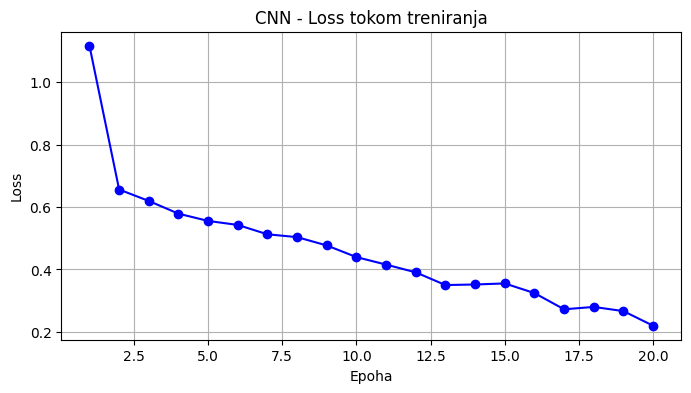

In [25]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, broj_epoha+1), loss_lista, marker='o', color='blue')
plt.title("CNN - Loss tokom treniranja")
plt.xlabel("Epoha")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

### Evaluacija 

In [26]:
model.eval()
tacnih = 0
ukupno = 0

with torch.no_grad():
    for slike, labele in test_dataloader:
        slike = slike.to(uredjaj)
        labele = labele.to(uredjaj)

        izlaz = model(slike)
        predikcije = izlaz.argmax(axis=1)
        tacnih += (predikcije == labele).sum().item()
        ukupno += labele.size(0)

print(f"Tacnost: {tacnih/ukupno*100:.2f}%")

Tacnost: 67.69%
